In [41]:
using Pkg
Pkg.instantiate()

In [42]:
using BootstrapAsymptotics
using QuadGK
using StableRNGs: StableRNG
using Plots
using Statistics
using ProgressBars

In [43]:
κ1    =  2.0 / sqrt(3* pi)
κstar = 0.200364

γ_range = 10 .^ range(-1, stop=3, length=100)
run_exp = false

sample_over_teacher = 5.0
Δ = 1.0
λ = 1e-2
ρ = 1.0

1.0

In [ ]:
q0_list = []
q1_list = []

m_list  = []
v_list  = []
ρ_list  = []

λ = 1.0

for γ in ProgressBar(γ_range)
    problem = BootstrapAsymptotics.build_logistic_overparametrized(
        α = sample_over_teacher / γ,
        true_Δ = Δ,
        λ = λ,
        true_ρ = 1.0,
        κ1 = κ1,
        κstar = κstar,
        student_over_teacher_dim = γ,
    )
    push!(ρ_list, problem.ρ)
    
    result = BootstrapAsymptotics.state_evolution(problem, FullResampling(), FullResampling())

    push!(q0_list, result.overlaps.Q[1, 1])
    push!(q1_list, result.overlaps.Q[1, 2])
    push!(m_list, result.overlaps.m[1])
    push!(v_list, result.overlaps.V[1, 1])
end

0.0%┣                                              ┫ 0/100 [00:00<00:00, -0s/it]
1.0%┣▍                                         ┫ 1/100 [00:01<Inf:Inf, InfGs/it]
2.0%┣█                                              ┫ 2/100 [00:02<02:46, 2s/it]
3.0%┣█▍                                             ┫ 3/100 [00:02<01:56, 1s/it]
4.0%┣█▉                                             ┫ 4/100 [00:03<01:38, 1s/it]
5.0%┣██▍                                            ┫ 5/100 [00:04<01:29, 1it/s]
6.0%┣██▉                                            ┫ 6/100 [00:04<01:23, 1it/s]
7.0%┣███▎                                           ┫ 7/100 [00:05<01:20, 1it/s]
8.0%┣███▊                                           ┫ 8/100 [00:06<01:18, 1it/s]
9.0%┣████▎                                          ┫ 9/100 [00:07<01:16, 1it/s]
10.0%┣████▌                                        ┫ 10/100 [00:08<01:16, 1it/s]
11.0%┣█████                                        ┫ 11/100 [00:08<01:15, 1it/s]
12.0%┣█████▍                

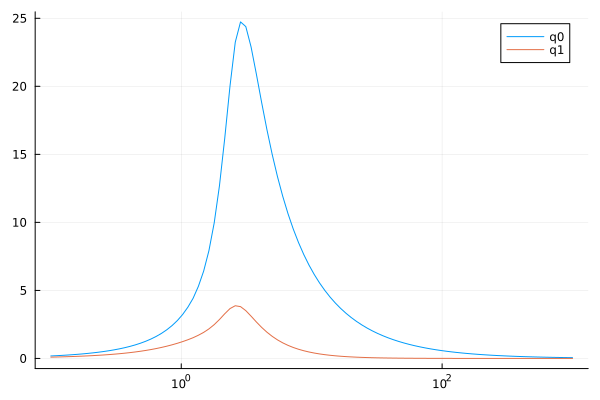

In [ ]:
plot(xscale=:log10)

# plot the cosine angle between the estimator w/ q0 and the teacher
cosine_q0 = m_list ./ sqrt.( ρ_list .* q0_list )

# plot the cosine angle between the averaged estimator w/ q1 and the teacher
cosine_q1 = m_list ./ sqrt.( ρ_list .* q0_list )

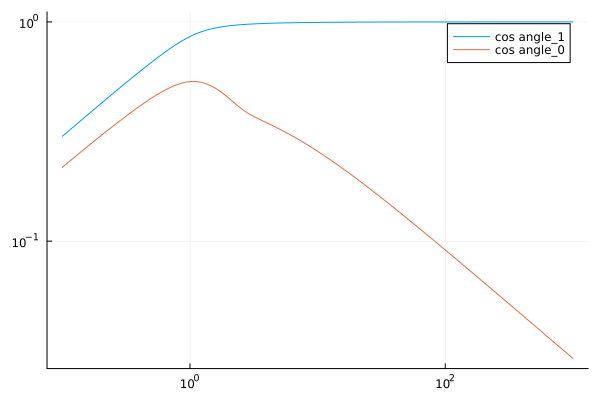

In [40]:
plot(xscale=:log10, yscale=:log10)

angle_1 = m_list ./ sqrt.(q1_list)
angle_0 = m_list ./ sqrt.(q0_list)
plot!(γ_range, angle_1, label="cos angle_1")
plot!(γ_range, angle_0, label="cos angle_0")

---

In [17]:
algos = [
    NoResampling(),
    Subsampling(r = 0.8),
    PairBootstrap()
]

# create an empty list for each algorithm
q0_list_dict = Dict()
for algo in algos
    q0_list_dict[algo] = []
end

q1_list_dict = Dict()
for algo in algos
    q1_list_dict[algo] = []
end

m_list_dict = Dict()
for algo in algos
    m_list_dict[algo] = []
end

exp_q0_list = Dict()
for algo in algos
    exp_q0_list[algo] = []
end
exp_q1_list = Dict()
for algo in algos
    exp_q1_list[algo] = []
end

scaling_list_dict = Dict()
for algo in algos
    scaling_list_dict[algo] = []
end

optimal_λ_list = []

for γ in ProgressBar(γ_range)
    Δ_add = BootstrapAsymptotics.get_additional_noise_from_kappas(κ1, κstar, γ)
    λ_optimal = BootstrapAsymptotics.compute_optimal_λ(sample_over_student_dim = sample_over_teacher / γ, Δ = Δ, ρ = ρ, κ1 = κ1, κstar = κstar, student_over_teacher_dim = γ)
    push!(optimal_λ_list, λ_optimal)

    # 
    problem = BootstrapAsymptotics.build_ridge_overparametrized(
    α = sample_over_teacher / γ,
    true_Δ = Δ,
    Δ̂ = 1.0,
    λ = λ_optimal,
    true_ρ = 1.0,
    κ1 = κ1,
    κstar = κstar,
    student_over_teacher_dim = γ,
    )

    for algo in algos
        result = BootstrapAsymptotics.state_evolution(
            problem, algo, algo
        )
        push!(q0_list_dict[algo], result.overlaps.Q[1, 1])
        push!(q1_list_dict[algo], result.overlaps.Q[1, 2])
        push!(m_list_dict[algo], result.overlaps.m[1])
        push!(scaling_list_dict[algo], BootstrapAsymptotics.get_scaling_gaussian_nll(result.overlaps, problem))
    end

   # 
   # do not include Δ_add in problem_exp as we generate the data with true Δ
   if !run_exp
       continue
   end

   problem_exp = BootstrapAsymptotics.RidgeOverparametrized(
    α       = sample_over_teacher / γ,
    Δ       = Δ,
    Δ̂       = 1.0,
    λ       = λ_optimal,
    ρ       = 1.0,
    κ1      = κ1,
    κstar   = κstar,
    student_over_teacher_dim = γ
    )

    exp_m, exp_Q = BootstrapAsymptotics.overlaps_empirical(
        StableRNG(0), problem_exp, algo; teacher_dim=500, K=5
    )

    # extract the diagonal and offdiagonal elements of exp_Q
    diag_Q = [exp_Q[i, i] for i in 1:size(exp_Q, 1)]
    offdiag_Q = [exp_Q[i, j] for i in 1:size(exp_Q, 1), j in 1:size(exp_Q, 2) if i != j]
    push!(exp_q0_list_dict, mean(diag_Q))
    push!(exp_q1_list_dict, mean(offdiag_Q))

end

0.0%┣                                              ┫ 0/200 [00:00<00:00, -0s/it]
0.5%┣▏                                         ┫ 1/200 [00:01<Inf:Inf, InfGs/it]
100.0%┣█████████████████████████████████████████┫ 200/200 [00:01<00:00, 179it/s]
100.0%┣█████████████████████████████████████████┫ 200/200 [00:01<00:00, 179it/s]


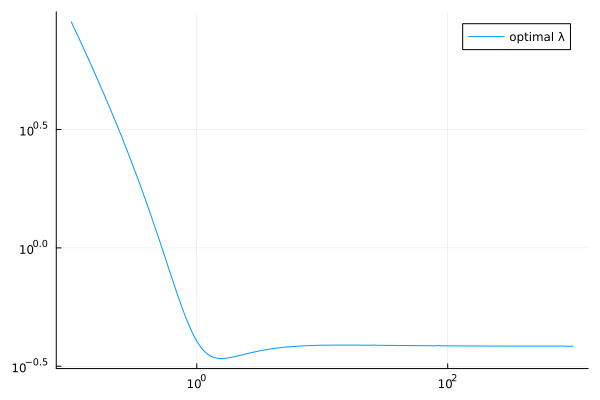

In [18]:
plot(γ_range, optimal_λ_list, label="optimal λ", xscale=:log10, yscale=:log10)

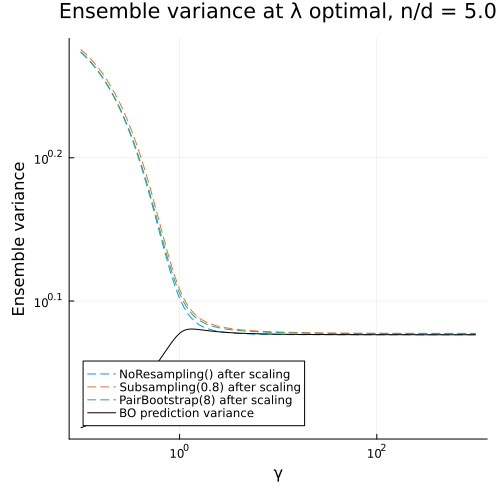

In [19]:
plot(size=(500, 500))

# for algo in algos
#     plot!(γ_range, (q0_list_dict[algo] .- q1_list_dict[algo]), label = "$algo before scaling")
# end

for algo in algos
    plot!(γ_range, (q0_list_dict[algo] .- q1_list_dict[algo]) ./ scaling_list_dict[algo], label = "$algo after scaling", linestyle = :dash)
end

if run_exp
    scatter!(γ_range, exp_q0_list .- exp_q1_list, label = "Empirical variance")
end

plot!(γ_range, bo_v_list .+ Δ, label = "BO prediction variance", color = :black)

plot!(title="Ensemble variance at λ optimal, n/d = $sample_over_teacher", xscale=:log10, yscale=:log10, xlabel="γ", ylabel="Ensemble variance", legend=:bottomleft)
# save the figure in plots/random_features folder
# savefig("plots/random_features/ensemble_variance_λ=$(λ)_n_d=$sample_over_teacher.png")

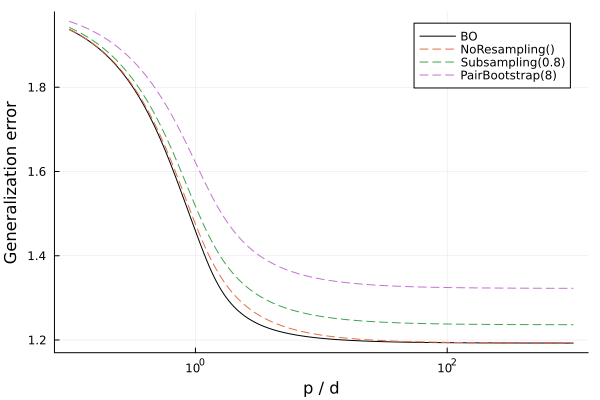

In [23]:
# plot the generalization error 
bo_gen_err = ρ .+ Δ .- 2.0 * bo_m_list .+ bo_q0_list

gen_err_dict = Dict(algo => ρ .+ Δ .- 2.0 * m_list_dict[algo] + q0_list_dict[algo] for algo in algos)

plot(γ_range, bo_gen_err, label = "BO", color = :black, xlabel="p / d", ylabel="Generalization error", xscale=:log10)
for algo in algos
    plot!(γ_range, gen_err_dict[algo], label = "$algo", linestyle = :dash)
end

display(plot!())

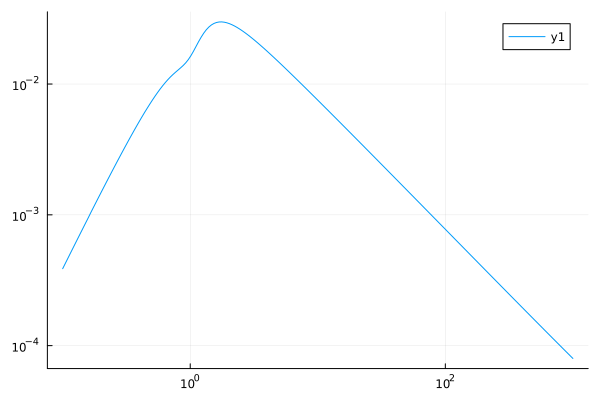

In [26]:
plot(γ_range, gen_err_dict[NoResampling()] - bo_gen_err, xscale=:log10, yscale = :log10)